**Business Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

**Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Data Description**

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

case_id: ID of each visa application
continent: Information of continent the employee
education_of_employee: Information of education of the employee
has_job_experience: Does the employee have any job experience? Y= Yes; N = No
requires_job_training: Does the employee require any job training? Y = Yes; N = No
no_of_employees: Number of employees in the employer's company
yr_of_estab: Year in which the employer's company was established
region_of_employment: Information of foreign worker's intended region of employment in the US.
prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
case_status: Flag indicating if the Visa was certified or denied

# Importing necessary libraries


In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# Loading the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df1 = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

In [4]:
df = df1.copy()

In [5]:
# Checking the number of rows and columns in the data
df.shape

(25480, 12)

# Displaying the first few rows of the dataset

In [6]:
# let's view the first 5 rows of the data
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [7]:
# let's view the last 5 rows of the data
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


# Checking the data types of the columns for the dataset

In [8]:
# let's check the data types of the columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* Most of the columns are in object types


# Checking for duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

* No Duplicate values.

# Checking for missing values

In [10]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


* No Missing values

In [11]:
# let's view the statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


In [12]:
# list of all categorical variables
cat_col = df.columns

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

case_id
EZYV25480   0.000
EZYV01      0.000
EZYV02      0.000
EZYV03      0.000
EZYV04      0.000
             ... 
EZYV13      0.000
EZYV12      0.000
EZYV11      0.000
EZYV10      0.000
EZYV09      0.000
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------
continent
Asia            0.662
Europe          0.146
North America   0.129
South America   0.033
Africa          0.022
Oceania         0.008
Name: proportion, dtype: float64
--------------------------------------------------
education_of_employee
Bachelor's    0.402
Master's      0.378
High School   0.134
Doctorate     0.086
Name: proportion, dtype: float64
--------------------------------------------------
has_job_experience
Y   0.581
N   0.419
Name: proportion, dtype: float64
--------------------------------------------------
requires_job_training
N   0.884
Y   0.116
Name: proportion, dtype: float64
--------------------------------------------------
no_of_employees
183     0.001
854 

In [13]:
# case_id is unique for each candidate and might not add value to modeling
df.drop(["case_id"], axis=1, inplace=True)

In [14]:
# Create a copy of data to perform detailed EDA in the appendix section.
data = df.copy()

# Exploratory Data Analysis (EDA) Summary

In [15]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [17]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [18]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 6))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

# Univariate Analysis

In [19]:
if 'case_id' in data.columns:
    data = data.drop(columns=['case_id'])

In [20]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)


Numeric columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


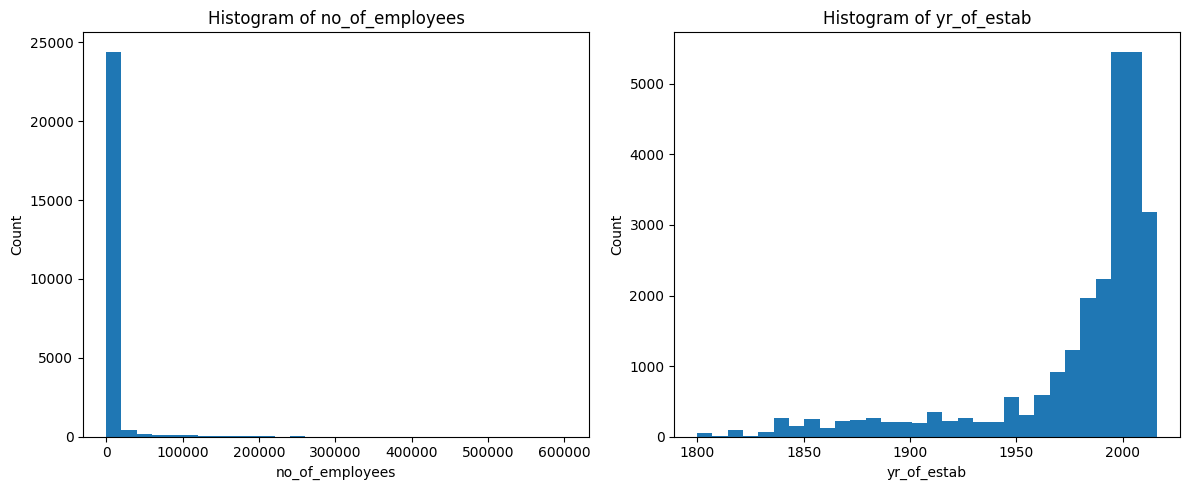

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot each histogram in its respective axis
for i, col in enumerate(numeric_cols[:2]):  # first 2 columns
    if col in data.columns:
        axes[i].hist(data[col].dropna(), bins=30)
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

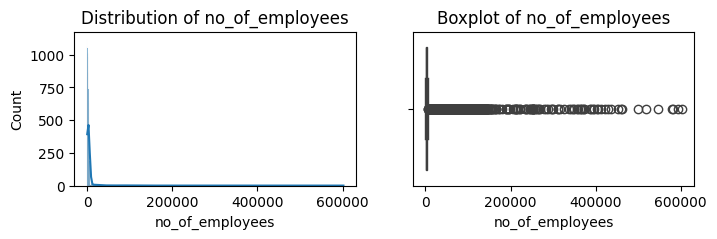

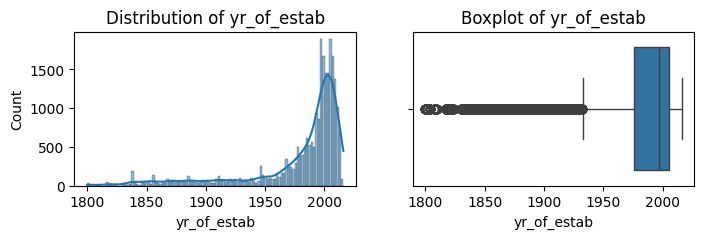

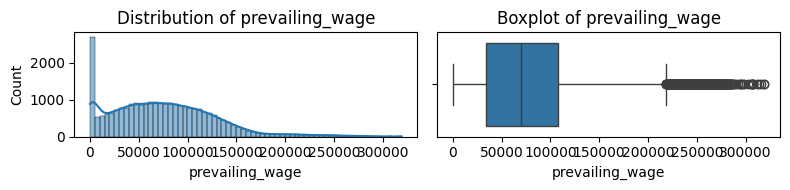

In [22]:
for col in numeric_cols:

    plt.figure(figsize=(8, 2))

    # --- Histogram ---
    plt.subplot(1, 2, 1)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")

    # --- Boxplot ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col].dropna())
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

**Observation**

* The distribution is highly right-skewed.
* The boxplot shows many outliers, indicating large variability.
* Here variable are not normally distributed and may need outlier treatment.
* year of est is highly left-skewed.
* The boxplot shows many outliers, indicating large variability.
* Prevaling age has highly right-skewed.



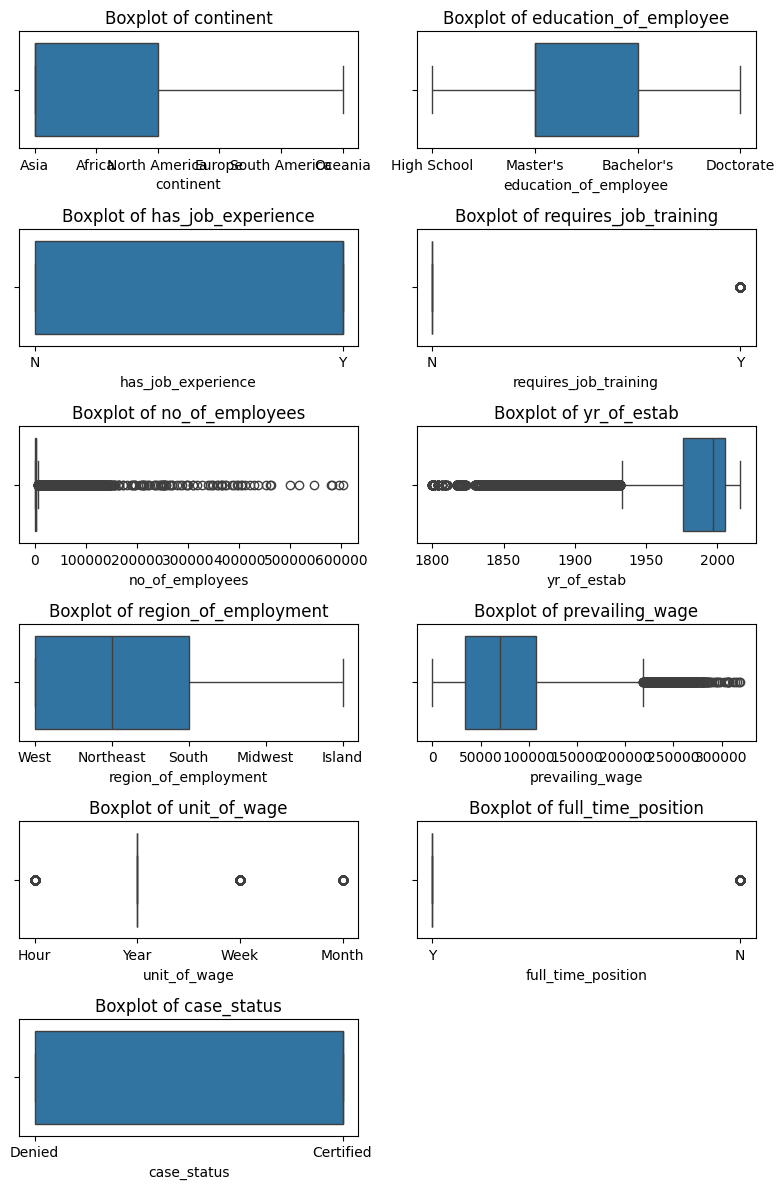

In [23]:
import math
cols = data.columns   # or your selected list

plots_per_row = 2
rows = math.ceil(len(cols) / plots_per_row)

plt.figure(figsize=(8, 2 * rows))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [24]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


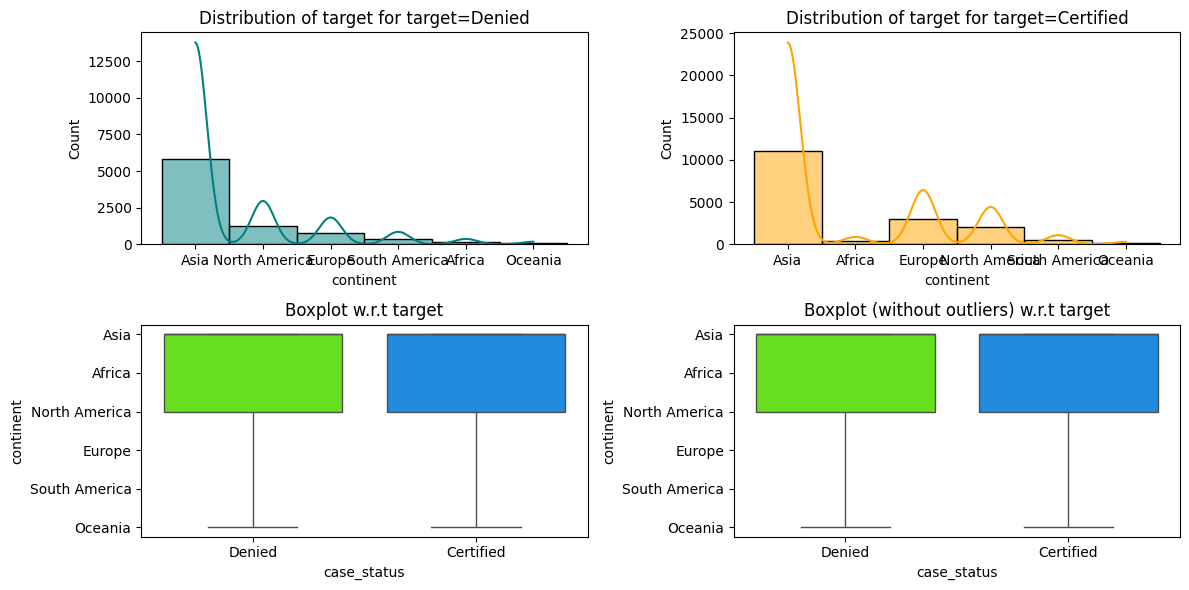

In [25]:
distribution_plot_wrt_target(data, "continent", "case_status")

Observation

* Asia shows higher number of denial accross all the continents.
* north America and Europe shows moderate denial.
* Africa, South America, and Oceania have very few denied cases.
* Asia has slightly higher number of certified
* Europe and north america has substatial certified counts.
* Overall, certifications are significantly higher than denials across all continents

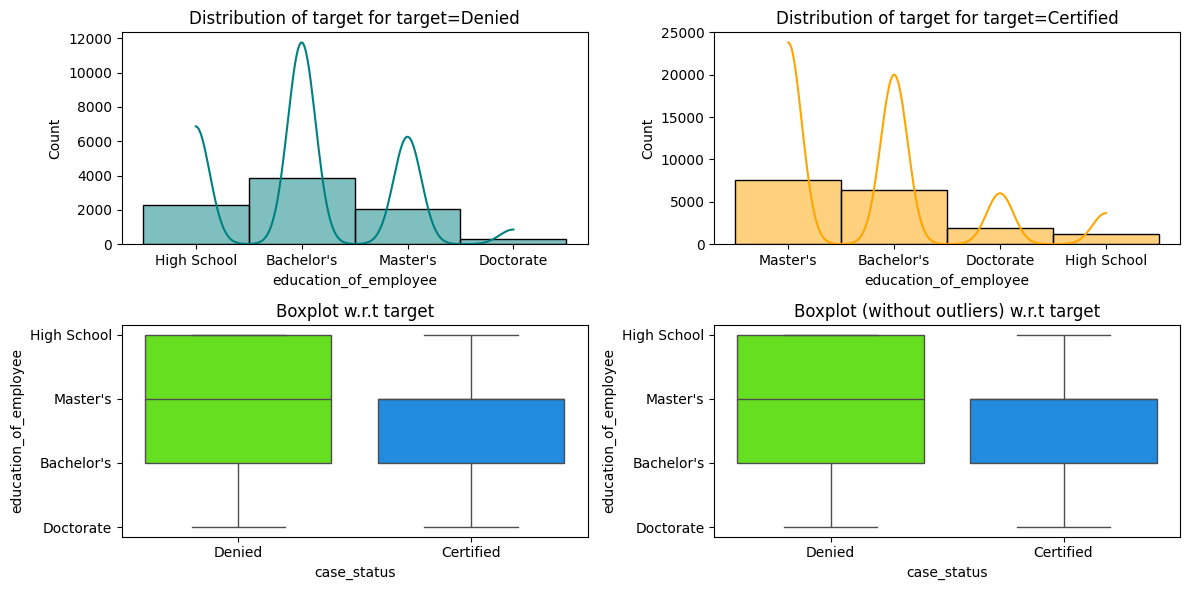

In [26]:
distribution_plot_wrt_target(data, "education_of_employee", "case_status")

**Observation**

* Higher number of denial application is from canditate holding bachelors degree.
* Master degree holder has noticable number of denial but fewer than bachelor degree holder.
* Doctrate holder has very fewer denial.
* Master’s degree holders have the highest number of certified visas.
* Bachelor’s degree holders also show strong certification counts
* Doctorate candidates have fewer applications but a relatively higher success rate.
* High School candidates have the lowest number of certifications.




case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


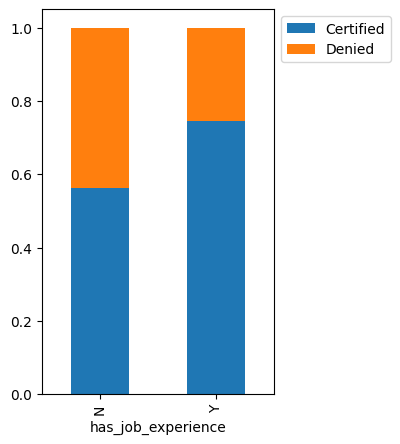

In [27]:
stacked_barplot(data, "has_job_experience", "case_status")

Observation

* Applicants with prior job experience have a much higher proportion of certified visas compared to denials.
* Applicant with no job exprience has more denial proportion compare to with exprience.
* certification rate is slightly higher compare to inexperienced applicants
* This indicates that the job exprience influence the visa approvals

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


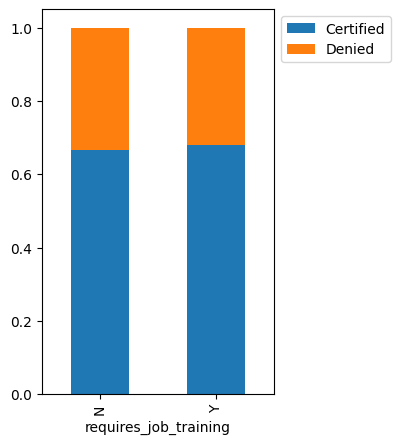

In [28]:
stacked_barplot(data, "requires_job_training", "case_status")

**Observation**

* The proportion of certified visa is slightly higher compare to denialsrequire training compared to those that do not..
* candiate who require training is slightly higher.
* Both categories show that certifications are significantly higher than denials overall.

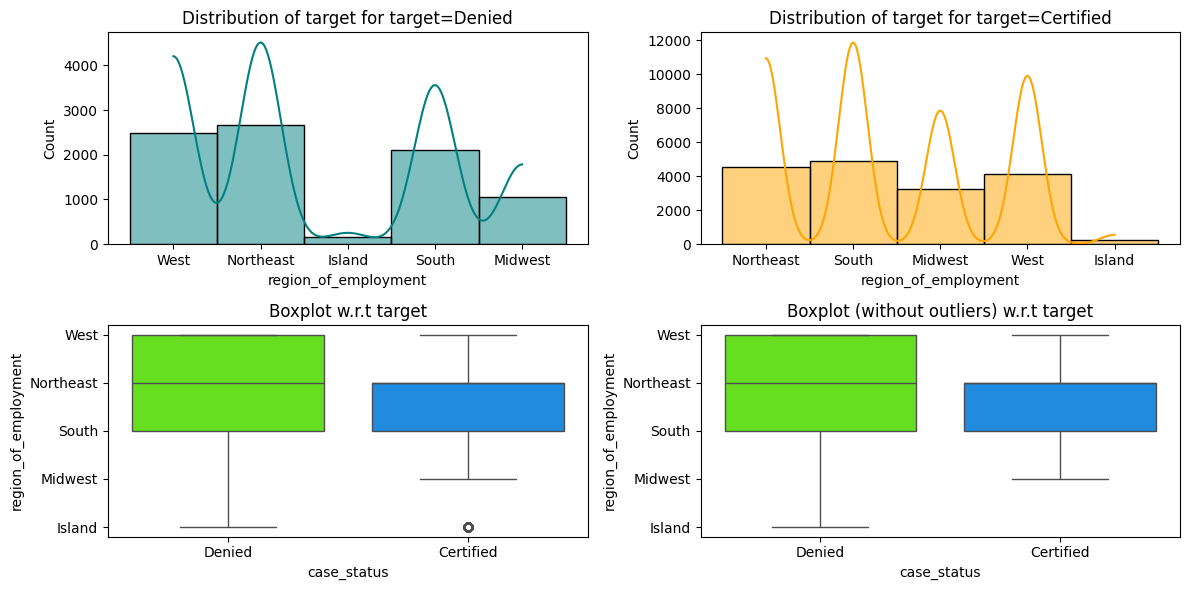

In [29]:
distribution_plot_wrt_target(data, "region_of_employment", "case_status")

In [30]:
data.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

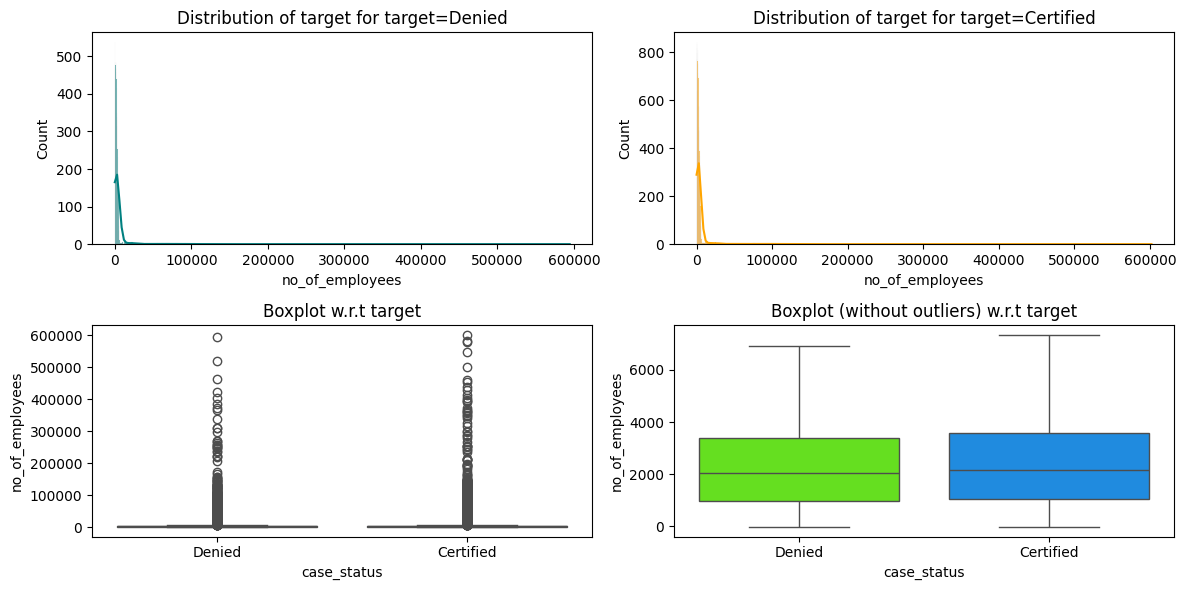

In [31]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

**Observation**

* Distribution is highly right skewed.
* most denial are comes from companies with small number of employees.
* This indicate that the smaller organisation account for visa dinials.
* Certification counts are generally higher than denials across all company sizes.
* no_of_employees does not follow a normal distribution and contains extreme outliers.
* Both certified and denied applications are dominated by small companies, likely due to higher volume.

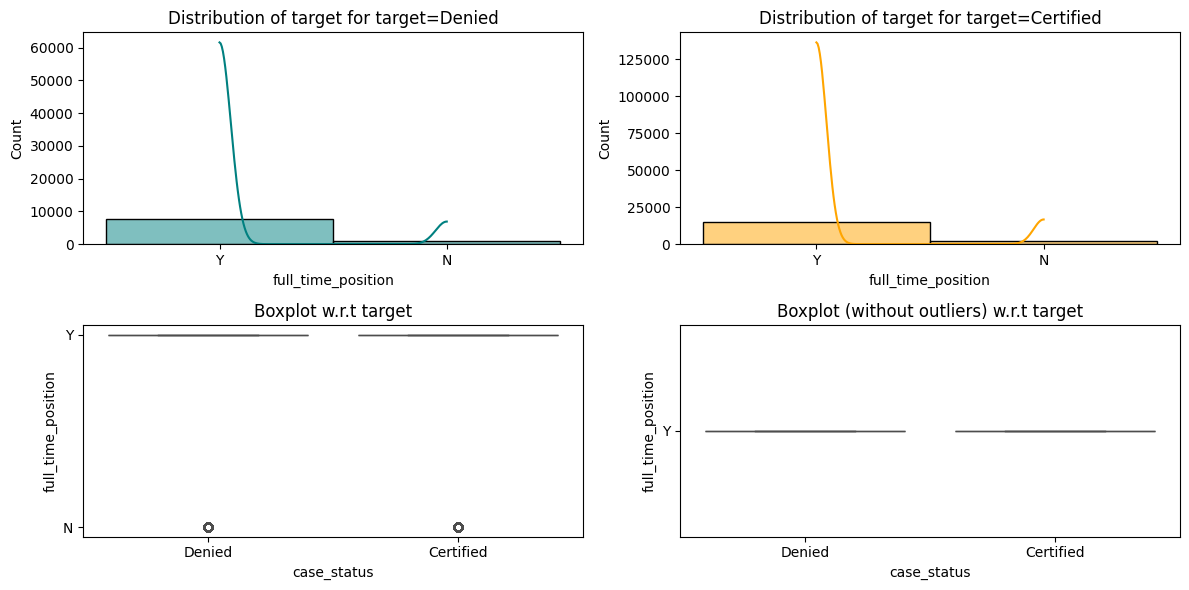

In [32]:
distribution_plot_wrt_target(data, "full_time_position", "case_status")

Observation

* majority of the application are denials for full time compare to non full time.
* majority of the application are certified for full time compare to non full time.
* full time position dominate visa approvals over all.
* Full-time roles have a much higher likelihood of certification compared to part-time or non-full-time roles.

In [33]:
data.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

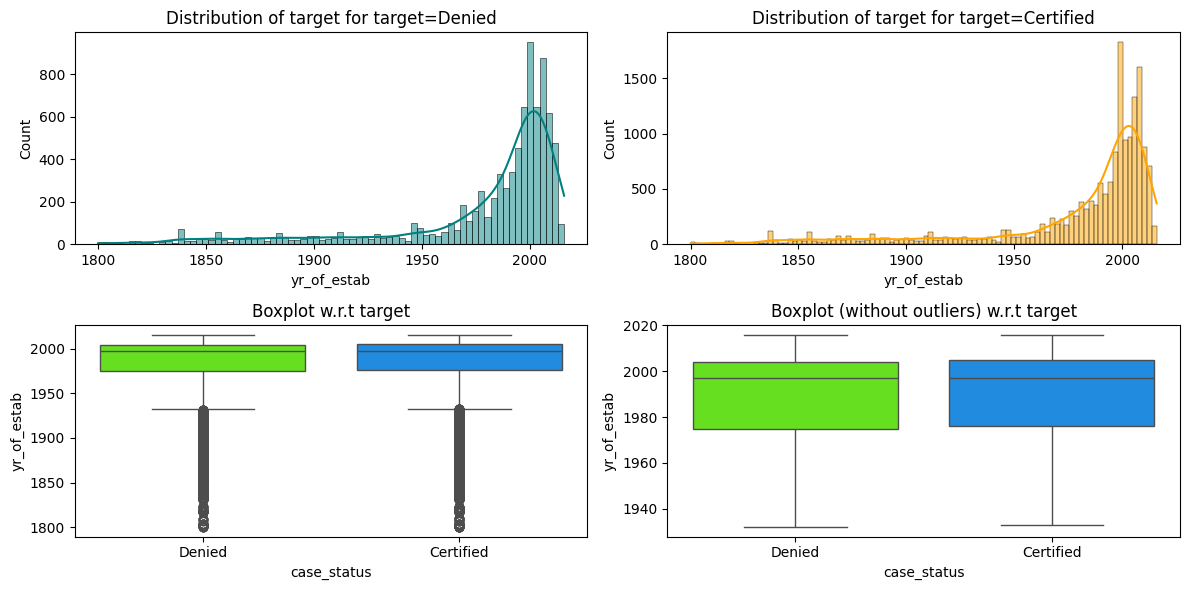

In [34]:
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


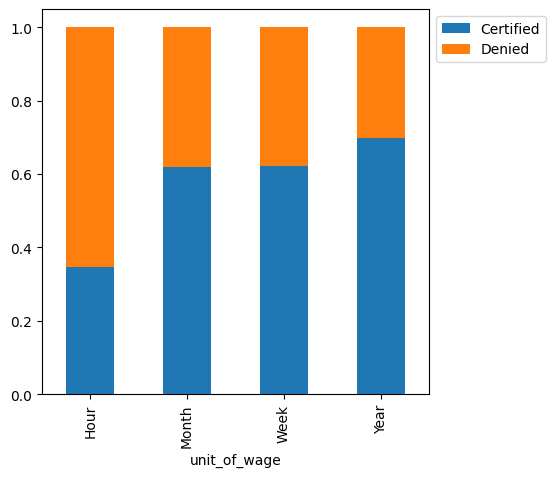

In [35]:
stacked_barplot(data, "unit_of_wage", "case_status")

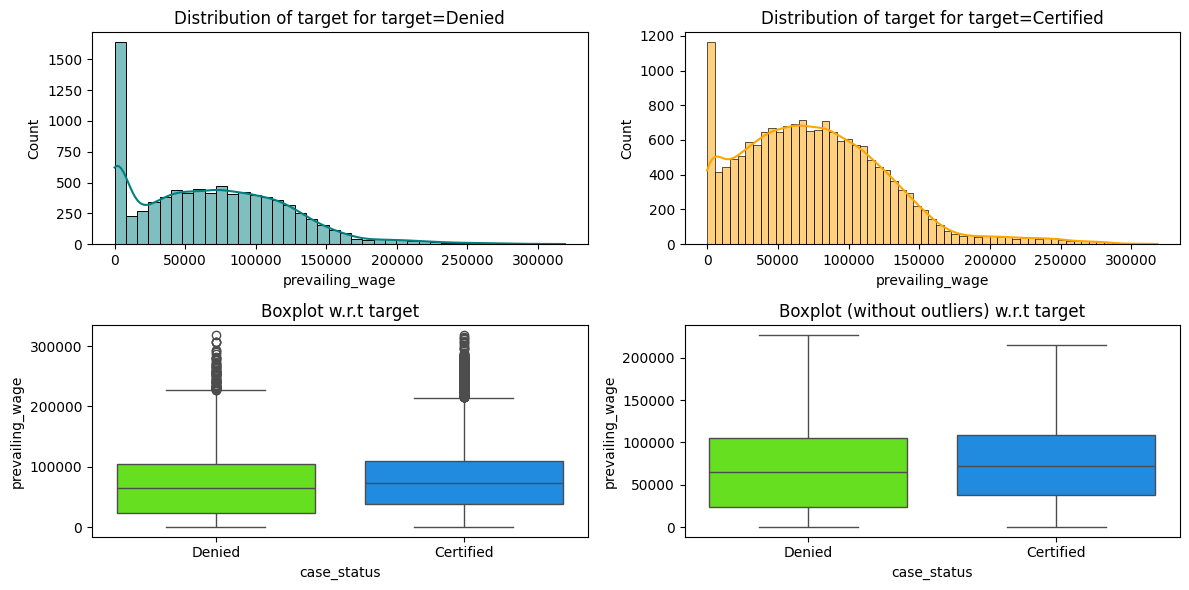

In [36]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

* We will do negative value imputation after splitting the data into train, test and validation to avoid data leakage

# Data Preprocessing

## Outlier Detection

In [37]:
numeric_col = data.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_col)

['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [38]:
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", cat_cols)


Categorical columns: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


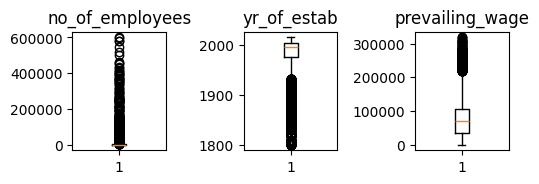

In [39]:
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(7, 8))

for i, variable in enumerate(numerical_col):
    plt.subplot(5, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Data preparing for modeling

In [40]:
df.duplicated().sum()


np.int64(0)

In [41]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [42]:
data["continent"].nunique()

6

In [43]:
data['continent'].describe()

,continent
count,25480
unique,6
top,Asia
freq,16861


In [44]:
data["education_of_employee"].describe()

,education_of_employee
count,25480
unique,4
top,Bachelor's
freq,10234


In [45]:
data['education_of_employee'].unique()

array(['High School', "Master's", "Bachelor's", 'Doctorate'], dtype=object)

In [46]:
data['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [47]:
data['region_of_employment'].unique()

array(['West', 'Northeast', 'South', 'Midwest', 'Island'], dtype=object)

In [48]:
data['unit_of_wage'].unique()

array(['Hour', 'Year', 'Week', 'Month'], dtype=object)

In [49]:
education_of_employee = {"High School": 0, "Master's": 1, "Bachelor's": 2, "Doctorate": 3}
data["education_of_employee"] = data["education_of_employee"].map(education_of_employee)

In [50]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,0,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,1,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,2,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,2,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,1,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [51]:
#data1['case_status'] = data1["case_status"].apply(lambda x: 1 if x == "certified" else 0)

In [52]:
#data1.head()

In [53]:
#data1['has_job_experience'] = data1["has_job_experience"].apply(lambda x: 1 if x == "Y" else 0)

In [54]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,0,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,1,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,2,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,2,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,1,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [55]:
data = df.copy()

In [56]:
data['case_status'].value_counts(1)

,proportion
case_status,
Certified,0.668
Denied,0.332


In [57]:
data['case_status'] = data['case_status'].map({'Certified':1, 'Denied':0})

In [58]:
data['case_status'].value_counts(1)

,proportion
case_status,
1,0.668
0,0.332


# Data Preparation for Modeling

In [59]:
X = data.drop(["case_status"], axis=1)
y = data["case_status"]

In [60]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [61]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


## Missing Value Treatment

In [62]:
for data in [X_train, X_val, X_test]:
    data.loc[df['no_of_employees'] < 0, 'no_of_employees'] = np.nan

In [63]:
#Fit imputer on training data only
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
imp_median.fit(X_train[['no_of_employees']])


SimpleImputer(strategy='median')

In [64]:
X_train[['no_of_employees']] = imp_median.transform(X_train[['no_of_employees']])
X_val[['no_of_employees']]   = imp_median.transform(X_val[['no_of_employees']])
X_test[['no_of_employees']]  = imp_median.transform(X_test[['no_of_employees']])

In [65]:
print("Train negatives:", (X_train['no_of_employees'] < 0).sum())
print("Val negatives:",   (X_val['no_of_employees'] < 0).sum())
print("Test negatives:",  (X_test['no_of_employees'] < 0).sum())

Train negatives: 0
Val negatives: 0
Test negatives: 0


* Verified no negative present

In [66]:
# Get list of categorical and numerical columns
cat_cols = list(X_train.select_dtypes(include='object').columns)
num_cols = list(X_train.select_dtypes(include=['int', 'float']).columns)

Train Dataset

In [67]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

continent
Asia             10085
Europe            2285
North America     1944
South America      528
Africa             333
Oceania            113
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     6141
Master's       5792
High School    2045
Doctorate      1310
Name: count, dtype: int64
******************************
has_job_experience
Y    8845
N    6443
Name: count, dtype: int64
******************************
requires_job_training
N    13477
Y     1811
Name: count, dtype: int64
******************************
region_of_employment
Northeast    4312
South        4248
West         3920
Midwest      2576
Island        232
Name: count, dtype: int64
******************************
unit_of_wage
Year     13786
Hour      1286
Week       156
Month       60
Name: count, dtype: int64
******************************
full_time_position
Y    13678
N     1610
Name: count, dtype: int64
******************************


In [68]:
#Validation Dataset
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

continent
Asia             3395
Europe            713
North America     655
South America     173
Africa            121
Oceania            39
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2033
Master's       1886
High School     694
Doctorate       483
Name: count, dtype: int64
******************************
has_job_experience
Y    2963
N    2133
Name: count, dtype: int64
******************************
requires_job_training
N    4501
Y     595
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1430
South        1389
West         1352
Midwest       855
Island         70
Name: count, dtype: int64
******************************
unit_of_wage
Year     4576
Hour      452
Week       57
Month      11
Name: count, dtype: int64
******************************
full_time_position
Y    4552
N     544
Name: count, dtype: int64
******************************


In [69]:
#Test Dataset
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)

continent
Asia             3381
Europe            734
North America     693
South America     151
Africa             97
Oceania            40
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2060
Master's       1956
High School     681
Doctorate       399
Name: count, dtype: int64
******************************
has_job_experience
Y    2994
N    2102
Name: count, dtype: int64
******************************
requires_job_training
N    4547
Y     549
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1453
South        1380
West         1314
Midwest       876
Island         73
Name: count, dtype: int64
******************************
unit_of_wage
Year     4600
Hour      419
Week       59
Month      18
Name: count, dtype: int64
******************************
full_time_position
Y    4543
N     553
Name: count, dtype: int64
******************************


* Creating Dummy Variables

In [70]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 21) (5096, 21) (5096, 21)


# Model Building


## Model evaluation criterion

For your visa-approval dataset, the most important metric is F1-score – balance of precision and recall

* Model Can Make Wrong Predictions As False Negative (Certified - Predicted as Denied)
* Model rejects a candidate who actually deserves certification.
* Business impact: Loss of skilled worker
* False Positive (Denied → Predicted as Certified)
* Model approves a candidate who should be denied.

In [71]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [72]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Initial Model Building

# Model Building - Original Data

In [73]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9892146288851849
Random forest: 1.0
GBM: 0.8289152182933014
Adaboost: 0.8199619254827305
dtree: 1.0

Validation Performance:

Bagging: 0.7773232028053769
Random forest: 0.804946599213041
GBM: 0.8256702319766634
Adaboost: 0.8185170012290045
dtree: 0.7444117647058823


In [74]:
import pandas as pd
from sklearn.metrics import f1_score

models = []

models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

results = []

for name, model in models:
    model.fit(X_train, y_train)

    train_f1 = f1_score(y_train, model.predict(X_train))
    val_f1   = f1_score(y_val, model.predict(X_val))

    results.append([name, train_f1, val_f1])

# Create DataFrame
performance_df = pd.DataFrame(results, columns=["Model", "Train F1", "Validation F1"])

print("Model Performance Comparison:")
performance_df


Model Performance Comparison:


,Model,Train F1,Validation F1
0,Bagging,0.989,0.777
1,Random Forest,1.000,0.805
2,GBM,0.829,0.826
3,AdaBoost,0.820,0.819
4,Decision Tree,1.000,0.744


In [75]:
X_train['no_of_employees'].min()

12.0

In [76]:
X_val['no_of_employees'].min()

12.0

In [77]:
X_test['no_of_employees'].min()

16.0

In [79]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9892, Validation Score: 0.7773, Difference: 0.2119
Random Forest: Training Score: 1.0000, Validation Score: 0.8049, Difference: 0.1951
GBM: Training Score: 0.8289, Validation Score: 0.8257, Difference: 0.0032
AdaBoost: Training Score: 0.8200, Validation Score: 0.8185, Difference: 0.0014
Decision Tree: Training Score: 1.0000, Validation Score: 0.7444, Difference: 0.2556


In [81]:
import pandas as pd
from sklearn.metrics import f1_score

rows = []

for name, model in models:
    model.fit(X_train, y_train)

    train_f1 = f1_score(y_train, model.predict(X_train))
    val_f1   = f1_score(y_val, model.predict(X_val))
    diff         = train_f1 - val_f1

    rows.append([name, train_f1, val_f1, diff])

# Create DataFrame
diff_df = pd.DataFrame(
    rows,
    columns=["Model", "Training f1", "Validation f1", "Difference"]
)

print("\nTraining and Validation Performance Difference:\n")
diff_df



Training and Validation Performance Difference:



,Model,Training f1,Validation f1,Difference
0,Bagging,0.989,0.777,0.212
1,Random Forest,1.000,0.805,0.195
2,GBM,0.829,0.826,0.003
3,AdaBoost,0.820,0.819,0.001
4,Decision Tree,1.000,0.744,0.256


* Here GBM has best performance, followed by AdaBoost as per validation performance.

# Model Building - Oversampled Data

In [82]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [84]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9874501697918204
Random forest: 0.9999510308016257
GBM: 0.8053953488372093
Adaboost: 0.7959035047792444
dtree: 1.0

Validation Performance:

Bagging: 0.7650665470315537
Random forest: 0.7985611510791367
GBM: 0.8152375517192182
Adaboost: 0.8127802690582959
dtree: 0.7261242292073996


In [85]:
import pandas as pd
from sklearn.metrics import f1_score

results = []

for name, model in models:
    model.fit(X_train_over, y_train_over)

    train_f1 = f1_score(y_train_over, model.predict(X_train_over))
    val_f1   = f1_score(y_val, model.predict(X_val))

    results.append([name, train_f1, val_f1])

# Create DataFrame
performance_df = pd.DataFrame(
    results,
    columns=["Model", "Train F1 (Oversampled)", "Validation F1"]
)

print("Model Performance (Oversampled Data):")
performance_df


Model Performance (Oversampled Data):


,Model,Train F1 (Oversampled),Validation F1
0,Bagging,0.987,0.765
1,Random forest,1.000,0.799
2,GBM,0.805,0.815
3,Adaboost,0.796,0.813
4,dtree,1.000,0.726


* In oversample Adaboost is performing best followed by GBM in validation performance.

# Model Building - Undersampled Data

In [86]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [87]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



In [88]:
import pandas as pd
from sklearn.metrics import f1_score

models = []
models.append(("Bagging", BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'),
    random_state=1
)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

rows = []

for name, model in models:
    model.fit(X_train_un, y_train_un)

    train_f1 = f1_score(y_train_un, model.predict(X_train_un))
    val_f1   = f1_score(y_val, model.predict(X_val))

    rows.append([name, train_f1, val_f1])

# Create DataFrame
performance_df = pd.DataFrame(
    rows,
    columns=["Model", "Train F1 (Undersampled)", "Validation F1"]
)

print("Model Performance (Undersampled Data):")
performance_df


Model Performance (Undersampled Data):


,Model,Train F1 (Undersampled),Validation F1
0,Bagging,0.981,0.704
1,Random Forest,1.000,0.743
2,GBM,0.727,0.777
3,AdaBoost,0.702,0.766
4,Decision Tree,1.000,0.699


* In undersampling dataset AdaBoost Model is performing best followed by GBM Model

In [90]:
import pandas as pd
from sklearn.metrics import f1_score

rows = []

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference = scores_train - scores_val

    rows.append({
        "Model": name,
        "Training F1": round(scores_train, 4),
        "Validation F1": round(scores_val, 4),
        "Difference (Train - Val)": round(difference, 4)
    })

f1_diff_df = pd.DataFrame(rows)
print("Training and Validation F1 Score Difference:\n")
f1_diff_df



Training and Validation F1 Score Difference:



,Model,Training F1,Validation F1,Difference (Train - Val)
0,Bagging,0.981,0.704,0.277
1,Random Forest,1.000,0.743,0.257
2,GBM,0.727,0.777,-0.050
3,AdaBoost,0.702,0.766,-0.065
4,Decision Tree,1.000,0.699,0.301


Observation

* Decision Tree: There is a Very large gap (0.301) - Strong overfitting.
* Bagging: Big gap (0.277) - Overfitting, though better than single tree.
* Random Forest: big gap Still overfitting, but validation performance is better than Bagging and Decision Tree.
* GBM: Negative gap (-0.050) → Good generalization, not overfitting.
* Validation performance is even better than training.
* Negative gap (-0.065) - Stable model, good generalization.
* AdaBoost: Stable model, good generalization.

# Hyperparameter Tuning

Tuning AdaBoostClassifier model with oversample data

In [94]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations → F1 score
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_over = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_jobs=-1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting on oversampled training data
randomized_cv_over.fit(X_train_over, y_train_over)

print(
    "Best parameters are {} with CV F1 score={}:".format(
        randomized_cv_over.best_params_, randomized_cv_over.best_score_
    )
)


Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 1, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV F1 score=0.7913114213626201:
CPU times: user 2.87 s, sys: 240 ms, total: 3.11 s
Wall time: 2min 3s


In [95]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=20, random_state=1)

In [96]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_over, y_train_over)
adb_train

,Accuracy,Recall,Precision,F1
0,0.693,0.892,0.638,0.744


In [97]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.735,0.895,0.754,0.818


# Tuning Gradient Boosting model with oversampled Data

In [98]:
%%time

# Defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid
param_grid = {
    "init": [AdaBoostClassifier(random_state=1), DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125, 175, 25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample": [0.8, 0.9, 1],
    "max_features": [0.5, 0.7, 1],
}

# Scorer → F1 score
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_over = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1,
)

# Fitting on oversampled data
randomized_cv_over.fit(X_train_over, y_train_over)

print(
    "Best parameters are {} with CV F1 score={}:".format(
        randomized_cv_over.best_params_, randomized_cv_over.best_score_
    )
)


Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(125), 'max_features': 0.5, 'learning_rate': 0.2, 'init': AdaBoostClassifier(random_state=1)} with CV F1 score=0.8008733230750986:
CPU times: user 8.94 s, sys: 990 ms, total: 9.93 s
Wall time: 12min 9s


In [99]:
# Tuned Gradient Boosting model trained on oversampled data
tuned_gbm_over = GradientBoostingClassifier(
    random_state=1,
    subsample=0.9,
    n_estimators=150,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)

tuned_gbm_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=150, random_state=1, subsample=0.9)

In [115]:
gbm_over_train = model_performance_classification_sklearn(
  tuned_gbm_over, X_train_over, y_train_over
)
gbm_over_train

,Accuracy,Recall,Precision,F1
0,0.764,0.893,0.710,0.791


In [106]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm_over, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.735,0.893,0.755,0.818


# Tuning Gradient Boosting model with under sample data

In [107]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1), DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75, 150, 25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample": [0.5, 0.7, 1],
    "max_features": [0.5, 0.7, 1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_un = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1,
)

# Fitting on undersampled training data
randomized_cv_un.fit(X_train_un, y_train_un)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv_un.best_params_, randomized_cv_un.best_score_
    )
)


Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7146145354767723:
CPU times: user 3.78 s, sys: 255 ms, total: 4.04 s
Wall time: 3min 46s


In [108]:
# Tuned Gradient Boosting model trained on undersampled data
tuned_gbm_un = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=1,
    learning_rate=1,
    init=AdaBoostClassifier(random_state=1),
)

tuned_gbm_un.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=1, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.7)

In [109]:
# Checking Gradient Boosting (undersampled, tuned) performance on training set
gbm_un_train = model_performance_classification_sklearn(
    tuned_gbm_un, X_train_un, y_train_un
)
gbm_un_train


,Accuracy,Recall,Precision,F1
0,0.726,0.748,0.717,0.732


In [110]:
# Checking Gradient Boosting (undersampled, tuned) performance on validation set
gbm_un_val = model_performance_classification_sklearn(
    tuned_gbm_un, X_val, y_val
)
gbm_un_val

,Accuracy,Recall,Precision,F1
0,0.709,0.716,0.826,0.767


# Tuning Random Forest model with Oversampled data

In [111]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

# Use F1 score instead of recall
scorer = metrics.make_scorer(metrics.f1_score)

# Calling RandomizedSearchCV
randomized_cv_rf_f1 = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

# Fitting on oversampled training data
randomized_cv_rf_f1.fit(X_train_over, y_train_over)

print(
    "Best parameters are {} with CV F1 score={}:"
    .format(randomized_cv_rf_f1.best_params_, randomized_cv_rf_f1.best_score_)
)


Best parameters are {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15} with CV F1 score=0.8057691264858106:
CPU times: user 9.54 s, sys: 868 ms, total: 10.4 s
Wall time: 14min 2s


In [116]:
# Tuned Random Forest model trained on oversampled data
tuned_rf_over = RandomForestClassifier(
    random_state=1,
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt"
)

tuned_rf_over.fit(X_train_over, y_train_over)

# Checking tuned Random Forest (oversampled) performance on training set
rf_over_train = model_performance_classification_sklearn(
    tuned_rf_over, X_train_over, y_train_over
)
rf_over_train

,Accuracy,Recall,Precision,F1
0,0.803,0.870,0.768,0.816


In [113]:
# Checking tuned Random Forest (oversampled) performance on validation set
rf_over_val = model_performance_classification_sklearn(
    tuned_rf_over, X_val, y_val
)
rf_over_val

,Accuracy,Recall,Precision,F1
0,0.755,0.858,0.792,0.824


Model Comparison and Final Model Selection

In [117]:
models_train_comp_df = pd.concat(
    [
        gbm_un_train.T,
        gbm_over_train.T,
        adb_train.T,
        rf_over_train.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Tuned Gradient Boosting (Undersampled)",
    "Tuned Gradient Boosting (Oversampled)",
    "Tuned AdaBoost (Oversampled)",
    "Tuned Random Forest (Oversampled)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Tuned Gradient Boosting (Undersampled),Tuned Gradient Boosting (Oversampled),Tuned AdaBoost (Oversampled),Tuned Random Forest (Oversampled)
Accuracy,0.726,0.764,0.693,0.803
Recall,0.748,0.893,0.892,0.870
Precision,0.717,0.710,0.638,0.768
F1,0.732,0.791,0.744,0.816


In [121]:
ada_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.721,0.889,0.743,0.810


In [120]:
print('Test Performance of Tuned Random Forest (Oversampled) on X_test:')
rf_test = model_performance_classification_sklearn(tuned_rf_over, X_test, y_test)
rf_test

Test Performance of Tuned Random Forest (Oversampled) on X_test:


,Accuracy,Recall,Precision,F1
0,0.732,0.848,0.773,0.808


In [118]:
models_val_comp_df = pd.concat(
    [
        gbm_un_val.T,
        gbm1_val.T,
        adb_val.T,
        rf_over_val.T,
    ],
    axis=1,
)

models_val_comp_df.columns = [
    "Tuned Gradient Boosting (Undersampled)",
    "Tuned Gradient Boosting (Oversampled)",
    "Tuned AdaBoost (Oversampled)",
    "Tuned Random Forest (Oversampled)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Tuned Gradient Boosting (Undersampled),Tuned Gradient Boosting (Oversampled),Tuned AdaBoost (Oversampled),Tuned Random Forest (Oversampled)
Accuracy,0.709,0.735,0.735,0.755
Recall,0.716,0.893,0.895,0.858
Precision,0.826,0.755,0.754,0.792
F1,0.767,0.818,0.818,0.824


In [119]:
models_val_comp_df = pd.concat(
    [
        gbm_un_val.T,
        gbm1_val.T,
        adb_val.T,
        rf_over_val.T,
    ],
    axis=1,
)

models_val_comp_df.columns = [
    "Tuned Gradient Boosting (Undersampled)",
    "Tuned Gradient Boosting (Oversampled)",
    "Tuned AdaBoost (Oversampled)",
    "Tuned Random Forest (Oversampled)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Tuned Gradient Boosting (Undersampled),Tuned Gradient Boosting (Oversampled),Tuned AdaBoost (Oversampled),Tuned Random Forest (Oversampled)
Accuracy,0.709,0.735,0.735,0.755
Recall,0.716,0.893,0.895,0.858
Precision,0.826,0.755,0.754,0.792
F1,0.767,0.818,0.818,0.824


In [122]:
ada_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.721,0.889,0.743,0.810


In [123]:
print('Test Performance of Tuned Random Forest (Oversampled) on X_test:')
rf_test = model_performance_classification_sklearn(tuned_rf_over, X_test, y_test)
rf_test

Test Performance of Tuned Random Forest (Oversampled) on X_test:


,Accuracy,Recall,Precision,F1
0,0.732,0.848,0.773,0.808


In [124]:
print('Test Performance of Tuned Gradient Boosting (Oversampled) on X_test:')
gbm_over_test = model_performance_classification_sklearn(tuned_gbm_over, X_test, y_test)
gbm_over_test

Test Performance of Tuned Gradient Boosting (Oversampled) on X_test:


,Accuracy,Recall,Precision,F1
0,0.722,0.890,0.744,0.810


In [125]:
print('Test Performance of Tuned Gradient Boosting (Undersampled) on X_test:')
gbm_un_test = model_performance_classification_sklearn(tuned_gbm_un, X_test, y_test)
gbm_un_test

Test Performance of Tuned Gradient Boosting (Undersampled) on X_test:


,Accuracy,Recall,Precision,F1
0,0.695,0.718,0.804,0.759


In [128]:
models_test_comp_df = pd.concat(
    [
        gbm_un_test.T,
        gbm_over_test.T,
        ada_test.T,
        rf_test.T,  # Corrected variable name from rf_over_test to rf_test
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Tuned Gradient Boosting (Undersampled)",
    "Tuned Gradient Boosting (Oversampled)",
    "Tuned AdaBoost (Oversampled)",
    "Tuned Random Forest (Oversampled)",
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Tuned Gradient Boosting (Undersampled),Tuned Gradient Boosting (Oversampled),Tuned AdaBoost (Oversampled),Tuned Random Forest (Oversampled)
Accuracy,0.695,0.722,0.721,0.732
Recall,0.718,0.890,0.889,0.848
Precision,0.804,0.744,0.743,0.773
F1,0.759,0.810,0.810,0.808


Observation
* Random Forest (Oversampled) is the best overall: